# Interpolation
This notebook runs a linear interpolation of SLA data in the month of Jan 2020.

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/mhen/.local/share/fonts/IBMPlexSerif-Regular.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.sans-serif"] = [font_prop.get_name()]

In [2]:
data_df = pd.read_csv('/home/mhen/geol0069_data/jan20.csv')

In [3]:
#keep data from january

data_df = data_df.loc[data_df['date_string'].str.contains('2020-01', na=False)]

In [4]:
data_df.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
2573650,-585146.902831,-432100.026835,-53.556094,83.483790,18262.0,NaN,1243,2020-01-01,cs2,0.0,0.000000,0.040157
2573651,-584280.987782,-430861.767792,-53.594113,83.496633,18262.0,-0.034818,1243,2020-01-01,cs2,1.0,1502.990248,0.040157
2573652,-584107.820675,-430614.140368,-53.601734,83.499201,18262.0,-0.018846,1243,2020-01-01,cs2,1.0,1803.558120,0.040157
2573653,-583934.553028,-430366.439101,-53.609361,83.501770,18262.0,NaN,1243,2020-01-01,cs2,0.0,2104.243152,0.040157
2573654,-583588.157115,-429871.156267,-53.624632,83.506906,18262.0,NaN,1243,2020-01-01,cs2,0.0,2705.434872,0.040157


In [65]:
test_track = data_df.loc[data_df['track'] == 1257]
test_track.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
2601689,-638579.271484,2.242111e+06,-164.10243,69.001559,18262.0,-0.746479,1257,2020-01-01,cs2,1.0,0.000000,-0.026275
2601690,-638462.214874,2.241838e+06,-164.10336,69.004244,18262.0,-0.798415,1257,2020-01-01,cs2,1.0,300.176217,-0.026275
2601691,-638111.488080,2.241019e+06,-164.10614,69.012299,18262.0,-0.665761,1257,2020-01-01,cs2,1.0,1200.652652,-0.026275
2601692,-637409.906412,2.239382e+06,-164.11171,69.028408,18262.0,-0.714593,1257,2020-01-01,cs2,1.0,3001.529271,-0.026275
2601693,-637292.936222,2.239109e+06,-164.11264,69.031093,18262.0,-0.669882,1257,2020-01-01,cs2,1.0,3301.699913,-0.026275


In [108]:
def random_holdout_test(data_df, holdout_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)

    #separate into tracks and iterate over each
    tracks = data_df['track'].unique()
    
    results_df = pd.DataFrame()
    results_metrics_df = pd.DataFrame()
    for i, track in enumerate(tracks):
        print(f'Interpolating track {track}, {i+1} of {len(tracks)}...')
        track_df = data_df.loc[data_df['track']==track]
        #locate leads
        leads_df = track_df.loc[track_df['lead_mask']==1.0]
        #create test (holdout) indices of length 1 or of holdout fraction, whichever is larger
        n_test = max(1, int(len(leads_df) * holdout_fraction))

        #exclude tracks with insufficient leads
        if len(leads_df) < 5:
            print(f"Insufficient leads ({len(leads_df)}) for random holdout, skipping...")
            continue

        #find lead indices and randomly select 80% for training
        leads_idx = leads_df.index
        test_lead_idx = rng.choice(leads_df.index, size=n_test, replace=False)
        train_lead_idx = np.array(leads_df.index.difference(test_lead_idx))

        # Compute distances before interpolation - nearest distance to a train lead of each test lead
        lead_D = leads_df.loc[leads_idx, 'dist_along_track'].to_numpy()
        train_D = leads_df.loc[train_lead_idx, 'dist_along_track'].to_numpy()
        test_D = leads_df.loc[test_lead_idx, 'dist_along_track'].to_numpy()
        if train_D.size > 0 and test_D.size > 0:
            nearest_dists_km = np.min(np.abs(test_D[:, None] - train_D[None, :]), axis=1) / 1000.0
        else:
            nearest_dists_km = np.array([])

        #run linear interpolation
        result_track = linear_interpolation(track_df, train_lead_idx)

        #find test values - withheld leads
        linear_preds = result_track.loc[test_lead_idx,'ssha'].to_numpy()
        targets = result_track.loc[test_lead_idx, 'z'].to_numpy()

        #check valid predictions
        both_valid = (np.isfinite(linear_preds) & np.isfinite(targets))
        if np.sum(both_valid) == 0:
            print(f"{prefix} FAILED: No valid predictions from linear on random holdout")
            results = None
            continue

        #find metrics for the prediction
        lin_res = linear_preds[both_valid] - targets[both_valid]
        def _r2(a, b):
            return np.corrcoef(a, b)[0,1]**2 if len(a) > 1 else np.nan
        
        # Distance and lead spacing stats
        dist_mean = float(np.nanmean(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_median = float(np.nanmedian(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_max = float(np.nanmax(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_min = float(np.nanmin(nearest_dists_km)) if nearest_dists_km.size else np.nan
        spacing_km = np.diff(lead_D) / 1000.0 if lead_D.size > 1 else np.array([])
        sp_med = float(np.nanmedian(spacing_km)) if spacing_km.size else np.nan
        sp_p90 = float(np.nanpercentile(spacing_km, 90)) if spacing_km.size else np.nan
        sp_max = float(np.nanmax(spacing_km)) if spacing_km.size else np.nan

        #add metrics to dataframe
        metrics_dict = {
            'n_predictions': int(np.sum(both_valid)),
            'n_train': int(len(train_lead_idx)),
            'n_test': int(len(test_lead_idx)),
            'nearest_train_km': {
                'mean': dist_mean, 'median': dist_median, 'max': dist_max, 'min': dist_min
            },
            'lead_spacing_km': {
                'median': sp_med, 'p90': sp_p90, 'max': sp_max
            },
            'linear': {
                'rmse': float(np.sqrt(np.mean(lin_res**2))),
                'bias': float(np.mean(lin_res)),
                'mae': float(np.mean(np.abs(lin_res))),
                'r2': float(_r2(linear_preds[both_valid], targets[both_valid]))
            }
        }
        track_metrics_df = pd.DataFrame(metrics_dict)
        results_metrics_df = pd.concat([results_metrics_df, track_metrics_df])
        results_df = pd.concat([results_df, result_track])
        print(f'Track interpolated!')
    print('All tracks interpolated')

    return results_df, results_metrics_df


def linear_interpolation(track_df, train_lead_idx, filter_width_km=100):
    obs_df = track_df['z']
    train_leads_df = track_df.loc[train_lead_idx]

    # apply 100 km box filter to smooth lead observations
    smoothed_obs_df = obs_df.copy()

    # For each lead point, smooth with nearby leads within filter_width_km
    for idx, lead in train_leads_df.iterrows():
        lead_distances = np.abs(train_leads_df['dist_along_track'] - train_leads_df['dist_along_track'].loc[idx])
        within_window = lead_distances <= (filter_width_km * 1000 / 2)  # ±50 km    
        if np.sum(within_window) > 0:
            smoothed_obs_df.loc[idx] = (train_leads_df['z'][within_window]).mean()

    # linear interpolation between smoothed lead values - covers all obs points
    obs_df = obs_df.to_frame()
    obs_df['ssha'] = np.nan
        
    for i0, i1 in zip(train_leads_df.index[:-1], train_leads_df.index[1:]):
        v0, v1 = smoothed_obs_df.loc[i0], smoothed_obs_df.loc[i1]
        span = i1 - i0
        if span <= 0:
            obs_df['ssha'].loc[i0] = v0
            continue
        ii = np.arange(i0, i1 + 1)
        obs_df['ssha'].loc[ii] = v0 + (v1 - v0) * (ii - i0) / span

    # flat extrapolation beyond the first/last training lead
    first_idx, last_idx = train_leads_df.index[0], train_leads_df.index[-1]
    obs_df.loc[:first_idx, 'ssha'] = smoothed_obs_df.loc[first_idx]
    obs_df.loc[last_idx:, 'ssha'] = smoothed_obs_df.loc[last_idx]

    track_df = pd.merge(track_df, obs_df['ssha'], left_index=True, right_index=True)
    track_df.head()

    return track_df

gpsat_interpolation()

In [ ]:
def _gpsat_core(self, stream_data, source_data, stream_name, mode='along', train_leads=None):
        """Core GPSat interpolation logic with optional training subset."""
        # Build dataframes
        df_pred = pd.DataFrame({
            'x': stream_data['x'],
            'y': stream_data['y'],
            't': stream_data['t'],
            'lon': stream_data['lon'],
            'lat': stream_data['lat'],
            'obs': stream_data['h'],
            'label': stream_data['lead_mask'].astype(int)
        })
        
        if mode == 'along':
            # Use same stream for source and prediction
            df_source = self._apply_lenient_leads(df_pred.copy(), stream_data['lenient_mask'])
            lead_data = df_source[df_source['processed_label'] > 0].copy()
            
            # Apply training subset if specified
            if train_leads is not None:
                # Filter lead_data to only include training leads
                train_indices = np.where(train_leads)[0]
                # Map back to lead_data indices
                all_lead_indices = np.where(df_source['processed_label'] > 0)[0]
                train_lead_mask = np.isin(all_lead_indices, train_indices)
                lead_data = lead_data[train_lead_mask].copy()
        else:
            # Use pre-built same-day source
            lead_data = source_data.copy()
            df_source = self._apply_lenient_leads(df_pred.copy(), stream_data['lenient_mask'])
        
        # Filter leads by height
        height_valid = (lead_data['obs'] >= -0.5) & (lead_data['obs'] <= 0.5)
        lead_data = lead_data[height_valid].copy()
        
        if len(lead_data) < 3:
            print(f"Insufficient leads for GPSat {mode}: {len(lead_data)}")
            return np.full(len(stream_data['h']), np.nan)
        
        # Diagnostics: effective training leads after filters
        print(f"[{stream_name}] GPSat training leads after filters: {len(lead_data)}")

        # Select experts
        experts = self._select_experts(lead_data)
        if len(experts) < 2:
            return np.full(len(stream_data['h']), np.nan)
        # Diagnostics: number of experts selected
        print(f"[{stream_name}] Experts selected: {len(experts)}")
        
        # Run GPSat
        store_path = f"/tmp/comp_{stream_name}_{mode}_{os.getpid()}.h5"
        if os.path.exists(store_path):
            os.remove(store_path)
        
        try:
            ssha = self._run_gpsat(lead_data, df_source, experts, store_path)
            return ssha
        finally:
            if os.path.exists(store_path):
                os.remove(store_path)

def _select_experts(self, lead_data, spacing=20e3, max_experts=128):
        """Select expert locations along track."""
        if len(lead_data) < 2:
            return lead_data
        
        x = lead_data['x'].values
        y = lead_data['y'].values
        dist = np.concatenate([[0], np.cumsum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))])
        
        if getattr(self, 'fast_mode', False):
            spacing = 100e3  # Denser experts for better coverage
            max_experts = min(max_experts, 32)
        elif getattr(self, 'full_mode', False):
            spacing = 25e3  # Notebook style: dense experts
            max_experts = 128
        grid = np.arange(0, dist[-1], spacing)
        selected = []
        used = set()
        
        for target in grid:
            if len(selected) >= max_experts:
                break
            idx = np.argmin(np.abs(dist - target))
            if idx not in used:
                selected.append(idx)
                used.add(idx)
        
        if len(selected) < 3:
            remaining = [i for i in range(len(lead_data)) if i not in used]
            step = max(1, len(remaining) // (max_experts - len(selected)))
            selected.extend(remaining[::step][:max_experts - len(selected)])
        
        return lead_data.iloc[selected].copy()

In [109]:
linear_df, linear_metrics_df = random_holdout_test(data_df)

Interpolating track 1243, 1 of 4638...
Track interpolated!
Interpolating track 1244, 2 of 4638...
Track interpolated!
Interpolating track 1245, 3 of 4638...
Track interpolated!
Interpolating track 1246, 4 of 4638...
Track interpolated!
Interpolating track 1247, 5 of 4638...
Track interpolated!
Interpolating track 1248, 6 of 4638...
Track interpolated!
Interpolating track 1249, 7 of 4638...


/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Track interpolated!
Interpolating track 1250, 8 of 4638...
Track interpolated!
Interpolating track 1251, 9 of 4638...
Track interpolated!
Interpolating track 1253, 10 of 4638...
Track interpolated!
Interpolating track 1254, 11 of 4638...
Track interpolated!
Interpolating track 1257, 12 of 4638...
Track interpolated!
Interpolating track 1258, 13 of 4638...
Track interpolated!
Interpolating track 1259, 14 of 4638...
Track interpolated!
Interpolating track 1260, 15 of 4638...
Track interpolated!
Interpolating track 1261, 16 of 4638...
Insufficient leads (0) for random holdout, skipping...
Interpolating track 1262, 17 of 4638...
Track interpolated!
Interpolating track 1263, 18 of 4638...
Track interpolated!
Interpolating track 1264, 19 of 4638...
Track interpolated!
Interpolating track 1265, 20 of 4638...
Track interpolated!
Interpolating track 1266, 21 of 4638...
Track interpolated!
Interpolating track 1267, 22 of 4638...
Insufficient leads (0) for random holdout, skipping...
Interpolatin

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_1460430/2962883892.py:56: RuntimeWarning: Mean of empty slice
  dist_mean = float(np.nanmean(nearest_dists_km)) if nearest_dists_km.size else np.nan
/tmp/ipykernel_1460430/2962883892.py:57: RuntimeWarning: All-NaN slice encountered
  dist_median = float(np.nanmedian(nearest_dists_km)) if nearest_dists_km.size else np.nan
/tmp/ipykernel_1460430/2962883892.py:58: RuntimeWarning: All-NaN slice encountered
  dist_max = float(np.nanmax(nearest_dists_km)) if nearest_dists_km.size else np.nan
/tmp/ipykernel_1460430/2962883892.py:59: RuntimeWarning: All-NaN slice encountered
  dist_min = float(np.nanmin(nearest_dists_km)) if ne

Track interpolated!
Interpolating track 1277, 32 of 4638...
Track interpolated!
Interpolating track 1278, 33 of 4638...
Track interpolated!
Interpolating track 1279, 34 of 4638...
Track interpolated!
Interpolating track 1280, 35 of 4638...
Track interpolated!
Interpolating track 1281, 36 of 4638...
Track interpolated!
Interpolating track 1282, 37 of 4638...
Track interpolated!
Interpolating track 1283, 38 of 4638...


...

/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Track interpolated!
Interpolating track 1962, 701 of 4638...
Track interpolated!
Interpolating track 1963, 702 of 4638...
Track interpolated!
Interpolating track 1964, 703 of 4638...
Track interpolated!
Interpolating track 1965, 704 of 4638...
Track interpolated!
Interpolating track 1966, 705 of 4638...
Track interpolated!
Interpolating track 1967, 706 of 4638...
Track interpolated!
Interpolating track 1968, 707 of 4638...
Track interpolated!
Interpolating track 1969, 708 of 4638...
Track interpolated!
Interpolating track 1970, 709 of 4638...
Track interpolated!
Interpolating track 1971, 710 of 4638...
Insufficient leads (0) for random holdout, skipping...
Interpolating track 1972, 711 of 4638...
Track interpolated!
Interpolating track 1973, 712 of 4638...
Track interpolated!
Interpolating track 1974, 713 of 4638...
Track interpolated!
Interpolating track 1975, 714 of 4638...
Track interpolated!
Interpolating track 1976, 715 of 4638...


/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mhen/miniconda3/envs/geol0069_gpsat/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Track interpolated!
Interpolating track 1977, 716 of 4638...
Track interpolated!
Interpolating track 1978, 717 of 4638...
Track interpolated!
Interpolating track 1979, 718 of 4638...
Insufficient leads (0) for random holdout, skipping...
Interpolating track 1980, 719 of 4638...
Track interpolated!
Interpolating track 1981, 720 of 4638...
Track interpolated!
Interpolating track 1982, 721 of 4638...
Track interpolated!
Interpolating track 1983, 722 of 4638...
Track interpolated!
Interpolating track 1984, 723 of 4638...
Track interpolated!
Interpolating track 1985, 724 of 4638...
Track interpolated!
Interpolating track 1987, 725 of 4638...
Track interpolated!
Interpolating track 1988, 726 of 4638...
Track interpolated!
Interpolating track 1989, 727 of 4638...
Track interpolated!
Interpolating track 1990, 728 of 4638...
Insufficient leads (0) for random holdout, skipping...
Interpolating track 1991, 729 of 4638...
Track interpolated!
Interpolating track 1992, 730 of 4638...
Track interpola

KeyboardInterrupt: 

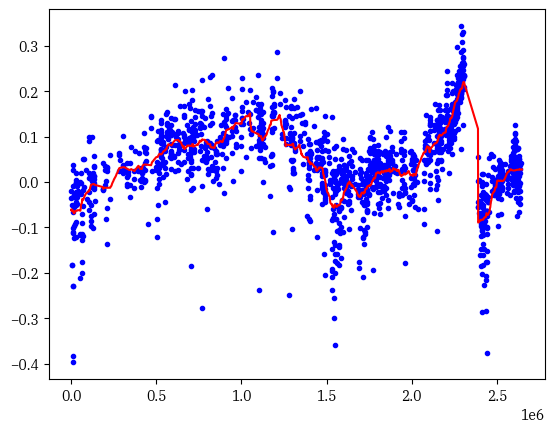

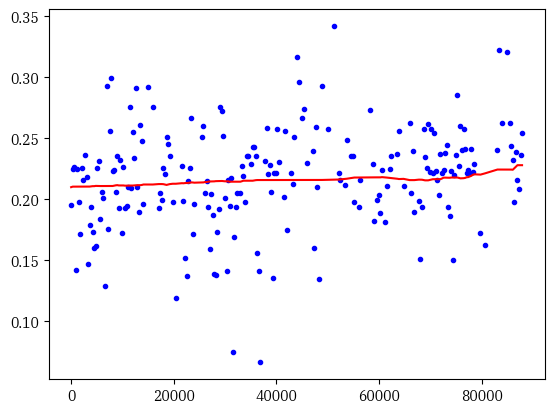

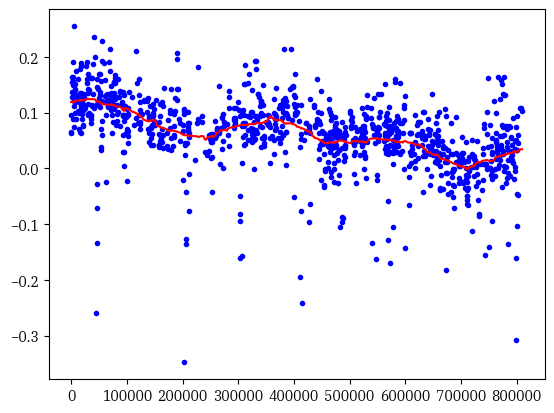

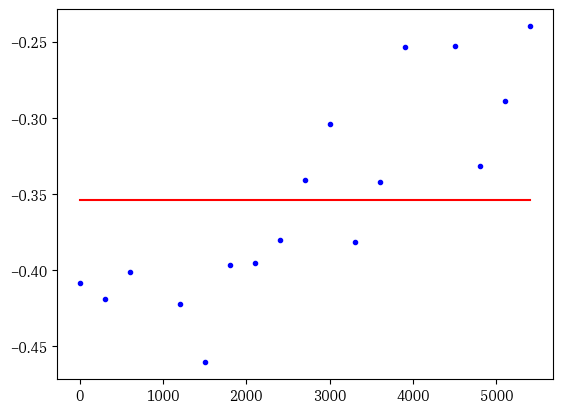

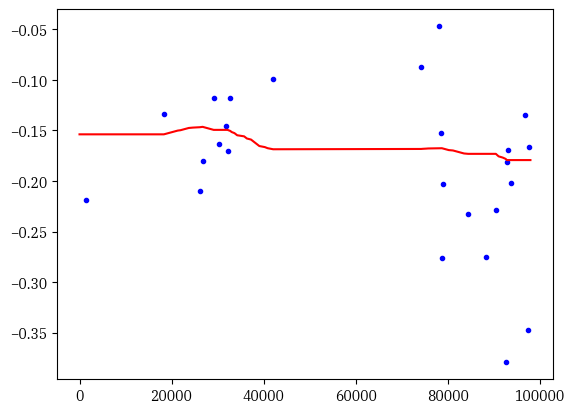

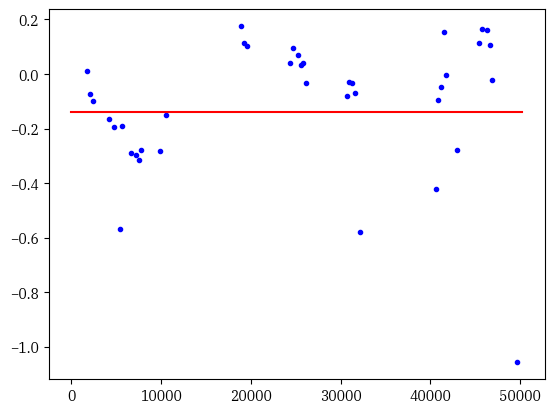

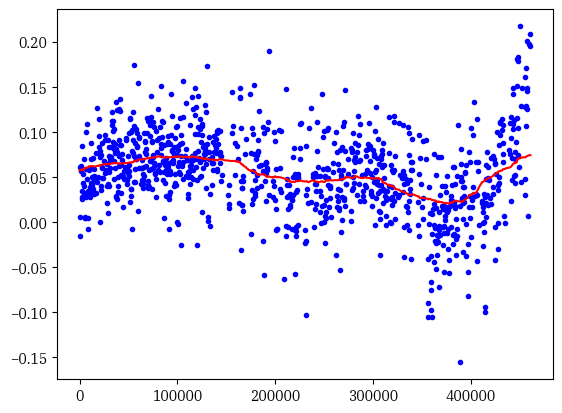

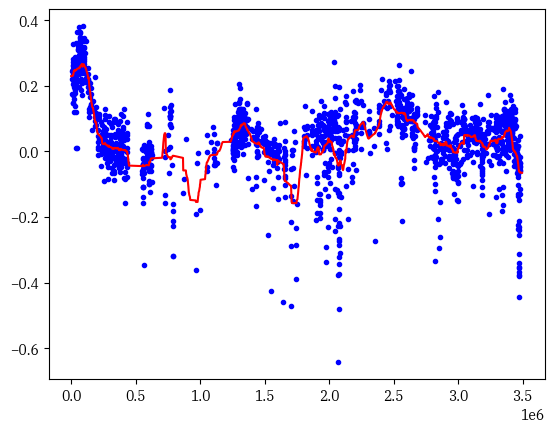

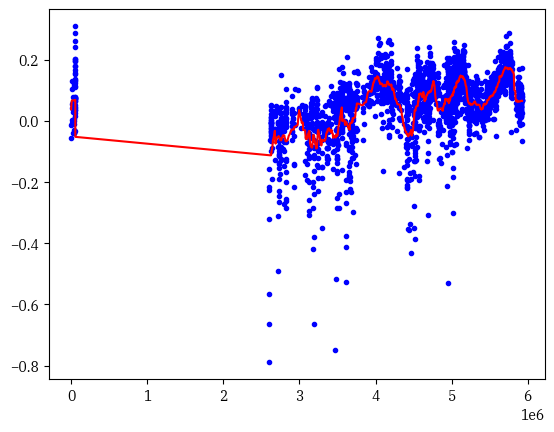

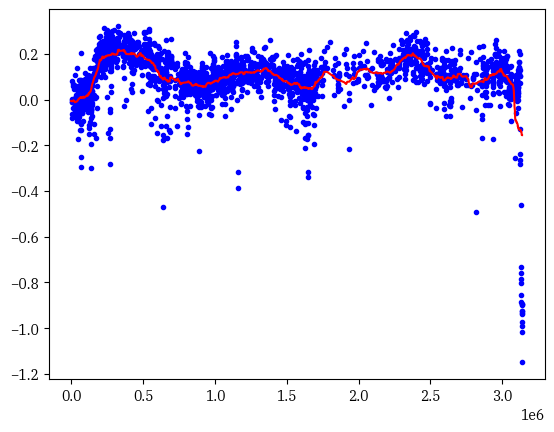

In [101]:
tracks = linear_df['track'].unique()

for track in tracks[:10]:
    track_df = linear_df.loc[linear_df['track']==track]

    dist_along_track = track_df['dist_along_track']
    z = track_df['z']
    ssha = track_df['ssha']

    plt.figure()
    plt.plot(dist_along_track, z, 'b.')
    plt.plot(dist_along_track, ssha, 'r-')
    plt.show()

In [ ]:
def random_holdout_test(self, holdout_fraction=0.2, seed=42, mode='random'):
        """Randomly hold out a fraction of leads and compare methods."""
        label = "Random" if mode == 'random' else "End-cap"
        print(f"\n{label} holdout test ({int(holdout_fraction*100)}% of leads)...")
        rng = np.random.default_rng(seed)
        results = {}
        for stream_name in ['plrm', 'sar']:
            prefix = f"[{stream_name.upper()}]"
            stream_data = self.data_plrm if stream_name == 'plrm' else self.data_sar
            lead_indices = np.where(stream_data['lead_mask'])[0]
            if len(lead_indices) < 5:
                print(f"{prefix} Insufficient leads ({len(lead_indices)}) for random holdout")
                results[stream_name] = None
                continue
            n_test = max(1, int(len(lead_indices) * holdout_fraction))
            if mode == 'random':
                test_lead_idx = rng.choice(lead_indices, size=n_test, replace=False)
                train_lead_idx = np.setdiff1d(lead_indices, test_lead_idx, assume_unique=True)
            else:
                k = n_test
                if 2 * k >= len(lead_indices):
                    k = max(1, (len(lead_indices) - 2) // 2)
                test_lead_idx = np.concatenate([lead_indices[:k], lead_indices[-k:]])
                train_lead_idx = lead_indices[k:-k]
            train_mask = np.zeros(len(stream_data['h']), dtype=bool)
            test_mask = np.zeros(len(stream_data['h']), dtype=bool)
            train_mask[train_lead_idx] = True
            test_mask[test_lead_idx] = True
            # Compute distances before interpolation
            D_m = np.concatenate([[0], np.cumsum(np.sqrt(np.diff(stream_data['x'])**2 + np.diff(stream_data['y'])**2))])
            lead_D = D_m[lead_indices]
            train_D = D_m[train_lead_idx]
            test_D = D_m[test_lead_idx]
            if train_D.size > 0 and test_D.size > 0:
                nearest_dists_km = np.min(np.abs(test_D[:, None] - train_D[None, :]), axis=1) / 1000.0
            else:
                nearest_dists_km = np.array([])
            linear_ssha = self.linear_interpolation(stream_data['h'], stream_data['lead_mask'], train_mask,
                                                     x_coords=stream_data['x'], y_coords=stream_data['y'])
            gpsat_ssha = self.gpsat_along_track(stream_data, f'{stream_name}_rand_holdout', train_mask)
            gpsat_variance_full = getattr(self, '_last_gpsat_variance', None)
            
            linear_preds = linear_ssha[test_mask]
            gpsat_preds = gpsat_ssha[test_mask]
            targets = stream_data['h'][test_mask]
            
            # Extract GPSat variance at test locations
            if gpsat_variance_full is not None:
                gpsat_variance_test = gpsat_variance_full[test_mask]
            else:
                gpsat_variance_test = None
            print(f"{prefix} Test NaNs — Linear: {np.sum(~np.isfinite(linear_preds))}, GPSat: {np.sum(~np.isfinite(gpsat_preds))}")
            both_valid = (np.isfinite(linear_preds) & np.isfinite(gpsat_preds) & np.isfinite(targets))
            if np.sum(both_valid) == 0:
                print(f"{prefix} FAILED: No valid predictions from both methods on random holdout")
                results[stream_name] = None
                continue
            lin_res = linear_preds[both_valid] - targets[both_valid]
            gp_res = gpsat_preds[both_valid] - targets[both_valid]
            def _r2(a, b):
                return np.corrcoef(a, b)[0,1]**2 if len(a) > 1 else np.nan
            
            # Calculate GPSat uncertainty at test leads for calibration check
            if gpsat_variance_test is not None:
                gpsat_std_test = np.sqrt(gpsat_variance_test[both_valid])
                avg_gpsat_uncertainty = float(np.mean(gpsat_std_test))
            else:
                avg_gpsat_uncertainty = None
            
            # Distance and lead spacing stats
            dist_mean = float(np.nanmean(nearest_dists_km)) if nearest_dists_km.size else np.nan
            dist_median = float(np.nanmedian(nearest_dists_km)) if nearest_dists_km.size else np.nan
            dist_max = float(np.nanmax(nearest_dists_km)) if nearest_dists_km.size else np.nan
            dist_min = float(np.nanmin(nearest_dists_km)) if nearest_dists_km.size else np.nan
            spacing_km = np.diff(lead_D) / 1000.0 if lead_D.size > 1 else np.array([])
            sp_med = float(np.nanmedian(spacing_km)) if spacing_km.size else np.nan
            sp_p90 = float(np.nanpercentile(spacing_km, 90)) if spacing_km.size else np.nan
            sp_max = float(np.nanmax(spacing_km)) if spacing_km.size else np.nan
            results[stream_name] = {
                'n_predictions': int(np.sum(both_valid)),
                'n_train': int(len(train_lead_idx)),
                'n_test': int(len(test_lead_idx)),
                'nearest_train_km': {
                    'mean': dist_mean, 'median': dist_median, 'max': dist_max, 'min': dist_min
                },
                'lead_spacing_km': {
                    'median': sp_med, 'p90': sp_p90, 'max': sp_max
                },
                'linear': {
                    'rmse': float(np.sqrt(np.mean(lin_res**2))),
                    'bias': float(np.mean(lin_res)),
                    'mae': float(np.mean(np.abs(lin_res))),
                    'r2': float(_r2(linear_preds[both_valid], targets[both_valid]))
                },
                'gpsat_along': {
                    'rmse': float(np.sqrt(np.mean(gp_res**2))),
                    'bias': float(np.mean(gp_res)),
                    'mae': float(np.mean(np.abs(gp_res))),
                    'r2': float(_r2(gpsat_preds[both_valid], targets[both_valid])),
                    'avg_uncertainty': avg_gpsat_uncertainty
                },
                # Store plot data for lead-based tests too
                'plot_data': {
                    'linear_preds': linear_preds[both_valid].copy(),
                    'gpsat_preds': gpsat_preds[both_valid].copy(),
                    'targets': targets[both_valid].copy(),
                    'nearest_dists_km': nearest_dists_km[both_valid] if nearest_dists_km.size > 0 else np.array([]),
                    'linear_residuals': lin_res.copy(),
                    'gpsat_residuals': gp_res.copy(),
                    # Store full arrays for along-track visualization
                    'linear_ssha_full': linear_ssha.copy(),
                    'gpsat_ssha_full': gpsat_ssha.copy(),
                    'gpsat_variance_full': getattr(self, '_last_gpsat_variance', None),  # Will be set during gpsat run
                    'train_mask': train_mask.copy(),
                    'test_lead_idx': test_lead_idx.copy()
                }
            }
            print(f"{prefix} {label} holdout: N_train={len(train_lead_idx)}, N_test={len(test_lead_idx)}")
            if nearest_dists_km.size:
                print(f"{prefix} Nearest-train distance (km): mean={dist_mean:.1f}, median={dist_median:.1f}, max={dist_max:.1f}")
            print(f"{prefix} Linear  — RMSE={results[stream_name]['linear']['rmse']:.4f}m, R²={results[stream_name]['linear']['r2']:.3f}")
            print(f"{prefix} GPSat   — RMSE={results[stream_name]['gpsat_along']['rmse']:.4f}m, R²={results[stream_name]['gpsat_along']['r2']:.3f}")
        # Store results with mode-specific attribute name
        if mode == 'random':
            self.random_holdout_results = results
        else:
            self.endcap_holdout_results = results
        # Save random holdout summary
        out_file = 'random_holdout_summary.txt' if mode == 'random' else 'endcap_holdout_summary.txt'
        out_path = self.output_dir / out_file
        with open(out_path, 'w') as f:
            title = "RANDOM HOLDOUT (20%) RESULTS" if mode == 'random' else "END-CAP HOLDOUT RESULTS"
            f.write(title + "\n")
            f.write("="*60 + "\n")
            for stream in ['plrm', 'sar']:
                f.write(f"\n{stream.upper()}\n")
                res = results.get(stream)
                if not res:
                    f.write("  No valid predictions.\n")
                    continue
                f.write(f"  N_train={res['n_train']}, N_test={res['n_test']}, N_valid={res['n_predictions']}\n")
                nd = res.get('nearest_train_km', {})
                if nd:
                    f.write(f"  Nearest-train distance (km): mean={nd.get('mean', float('nan')):.1f}, median={nd.get('median', float('nan')):.1f}, max={nd.get('max', float('nan')):.1f}, min={nd.get('min', float('nan')):.1f}\n")
                ls = res.get('lead_spacing_km', {})
                if ls:
                    f.write(f"  Lead spacing (km): median={ls.get('median', float('nan')):.1f}, p90={ls.get('p90', float('nan')):.1f}, max={ls.get('max', float('nan')):.1f}\n")
                f.write(f"  Linear: RMSE={res['linear']['rmse']:.4f}m, Bias={res['linear']['bias']:.4f}m, MAE={res['linear']['mae']:.4f}m, R²={res['linear']['r2']:.3f}\n")
                gpsat_line = f"  GPSat : RMSE={res['gpsat_along']['rmse']:.4f}m, Bias={res['gpsat_along']['bias']:.4f}m, MAE={res['gpsat_along']['mae']:.4f}m, R²={res['gpsat_along']['r2']:.3f}"
                if res['gpsat_along'].get('avg_uncertainty') is not None:
                    gpsat_line += f", AvgUnc={res['gpsat_along']['avg_uncertainty']:.4f}m"
                f.write(gpsat_line + "\n")
        print(f"{label} holdout test completed. Summary written to {out_file}")
        return results